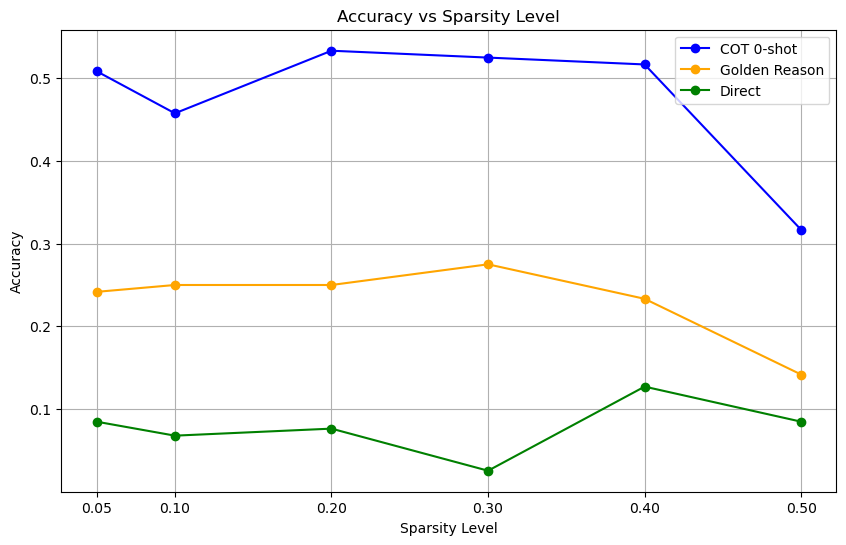

In [1]:
sparsity_levels = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
cot0shot_acc = [0.5085, 0.4576, 0.5333, 0.5250, 0.5167, 0.3167]
golden_reason_acc = [0.2417, 0.2500, 0.2500, 0.2750, 0.2333, 0.1417]
direct_acc = [0.0847, 0.0678, 0.0763, 0.0254, 0.1271, 0.0847]
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.plot(sparsity_levels, cot0shot_acc, marker='o', label='COT 0-shot', color='blue')
plt.plot(sparsity_levels, golden_reason_acc, marker='o', label='Golden Reason', color='orange')
plt.plot(sparsity_levels, direct_acc, marker='o', label='Direct', color='green')
plt.xlabel('Sparsity Level')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Sparsity Level')
plt.xticks(sparsity_levels)
plt.grid(True)
plt.legend()

In [8]:
prune_data_options = ["GSM8K_direct_120", "GSM8K_cot0shot_120", "GSM8K_cot0shot_goldreason"]
sparsity_ratios = [0, 0.03, 0.06, 0.09, 0.12, 0.15]
prune_method_options = ["random", "wanda"]
prompt_methods = ["direct", "cot0shot", "cot0shot_goldreason"]
model = "llama2-7b-chat-hf"  # 可改为变量
sparsity_type = "unstructured"  # 也可以设为参数

import os
from pathlib import Path

# 记录最终结果
summary_lines = []

# 遍历所有组合
for prune_data in prune_data_options:
    for prune_method in prune_method_options:
        for sparsity_ratio in sparsity_ratios:
            for prompt_method in prompt_methods:
                suffix = f"weightonly"
                save_dir = f"/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/{model}/{sparsity_type}/{prune_method}_{suffix}/{prune_data}/sparsity_{sparsity_ratio}"
                log_file = os.path.join(save_dir, f"log_{prune_method}.txt")
# /common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/llama2-7b-chat-hf/unstructured
                if not os.path.exists(log_file):
                    continue

                # 读取 log 文件，查找带 held_out 的最新一行
                with open(log_file, "r") as f:
                    lines = f.readlines()

                held_out_lines = [line.strip() for line in lines if "held_out" in line]
                if held_out_lines:
                    summary_lines.append(held_out_lines[-1])  # 最后一条 held_out 结果

# 保存所有 held_out 结果汇总
output_txt = "held_out_summary.txt"
with open(output_txt, "w") as out:
    for line in summary_lines:
        out.write(line + "\n")

print(f"共记录 {len(summary_lines)} 条 held-out 结果，已写入 {output_txt}")


共记录 15 条 held-out 结果，已写入 held_out_summary.txt


In [ ]:
prune_data_options = ["GSM8K_direct_120", "GSM8K_cot0shot_120", "GSM8K_cot0shot_goldreason"]
sparsity_ratios = [0, 0.03, 0.06, 0.09, 0.12, 0.15] # [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
prune_method_options = ["random", "wanda"]
prompt_methods = ["direct", "cot0shot", "cot0shot_goldreason"]
model = "llama2-7b-chat-hf"  # 可改为变量
sparsity_type = "unstructured"  # 也可以设为参数

import os
from pathlib import Path

# 记录最终结果
summary_lines = []

# 遍历所有组合
for prune_data in prune_data_options:
    for prune_method in prune_method_options:
        for sparsity_ratio in sparsity_ratios:
            for prompt_method in prompt_methods:
                suffix = f"weightonly"
                save_dir = f"/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/{model}/{sparsity_type}/{prune_method}_{suffix}/{prune_data}/sparsity_{sparsity_ratio}"
                log_file = os.path.join(save_dir, f"log_{prune_method}.txt")
# /common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/out/llama2-7b-chat-hf/unstructured
                if not os.path.exists(log_file):
                    continue

                # 读取 log 文件，查找带 held_out 的最新一行
                with open(log_file, "r") as f:
                    lines = f.readlines()

                held_out_lines = [line.strip() for line in lines if "held_out" in line]
                if held_out_lines:
                    summary_lines.append(held_out_lines[-1])  # 最后一条 held_out 结果

# 保存所有 held_out 结果汇总
output_txt = "held_out_summary_3*3.txt"
with open(output_txt, "w") as out:
    for line in summary_lines:
        out.write(line + "\n")

print(f"共记录 {len(summary_lines)} 条 held-out 结果，已写入 {output_txt}")


共记录 96 条 held-out 结果，已写入 held_out_summary_previous.txt
